# WarpKriging with ordinal warping (Julia)

The **ordinal** warp maps each level $\ell \in \{0, \ldots, L-1\}$ to a learned position
on $\mathbb{R}$, respecting the natural ordering. This is appropriate when one input is
discrete and ordered (e.g., resolution level, quality grade).

Here we discretize $x_1$ of the Branin function into 5 ordered levels while keeping $x_2$ continuous.

Steps:
1. Setup mlibkriging / jlibkriging
2. Define the Branin function and plot it
3. Build a space-filling design and evaluate it
4. Fit a `WarpKriging` model
5. Predict on a fine grid and plot mean + uncertainty
6. Inspect model parameters

## 0. Setup

Build the C++ core and install the Julia binding (skip if already done).
Requires: `cmake`, a C++ compiler, Julia ≥ 1.10.

```shell
julia -e 'using Pkg; Pkg.develop(path="bindings/Julia/jlibkriging")'
```

In [1]:
using jlibkriging
using Plots
using Random

println("jlibkriging loaded")

jlibkriging loaded


## 1. Branin function

The Branin function is a standard benchmark for surrogate modelling, defined on $[0,1]^2$
(rescaled from its canonical domain $[-5, 10] \times [0, 15]$).
It has three global minima.

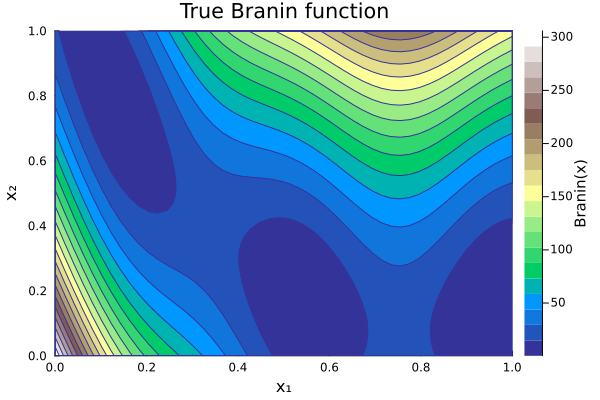

In [2]:
function branin(X::Matrix{Float64})
    x1 = X[:, 1] .* 15 .- 5
    x2 = X[:, 2] .* 15
    return (x2 .- 5 ./ (4π^2) .* x1.^2 .+ 5 ./ π .* x1 .- 6).^2 .+
           10 .* (1 - 1 / (8π)) .* cos.(x1) .+ 10
end

# 50×50 evaluation grid
grid_x = range(0, 1, length=50)
G1 = [x1 for x2 in grid_x, x1 in grid_x]
G2 = [x2 for x2 in grid_x, x1 in grid_x]
grid_pts = hcat(vec(G1), vec(G2))
z_true = reshape(branin(grid_pts), 50, 50)

contourf(collect(grid_x), collect(grid_x), z_true,
         levels=20, color=:terrain, xlabel="x₁", ylabel="x₂",
         title="True Branin function", colorbar_title="Branin(x)")

## 2. Design of experiments

We discretize $x_1$ into 5 ordinal levels (0, 1, ..., 4), each mapped to an
equally spaced center in $[0, 1]$, and sample $n = 40$ points.

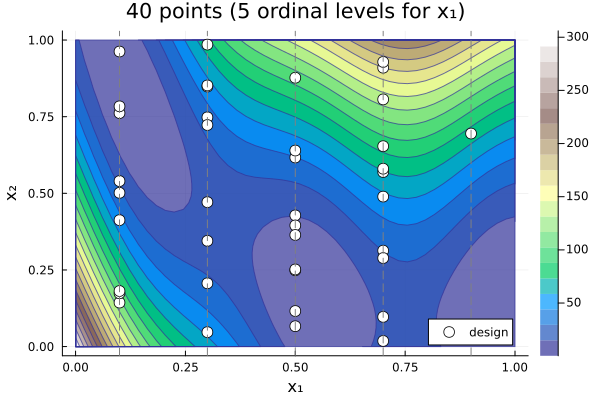

In [3]:
Random.seed!(42)

L = 5  # number of ordinal levels
n = 40
centers = range(0.1, 0.9, length=L)

function lhs(n::Int, d::Int)
    X = zeros(n, d)
    for j in 1:d
        perm = randperm(n)
        X[:, j] = (perm .- rand(n)) ./ n
    end
    return X
end

# x1 is ordinal: randomly assign levels
x1_level = rand(0:L-1, n)
x2 = lhs(n, 1)[:, 1]

# Evaluate Branin at the level's center for x1
X_eval = hcat([centers[l+1] for l in x1_level], x2)
y = branin(X_eval)

# For WarpKriging, x1 is passed as integer level (0..L-1)
X = hcat(Float64.(x1_level), x2)

p = contourf(collect(grid_x), collect(grid_x), z_true,
             levels=20, color=:terrain, alpha=0.7,
             xlabel="x₁", ylabel="x₂",
             title="$n points ($L ordinal levels for x₁)")
scatter!(p, X_eval[:, 1], X_eval[:, 2],
         mc=:white, msc=:black, ms=6, label="design")
for lvl in 1:L
    vline!(p, [centers[lvl]], color=:grey, linestyle=:dash, label="")
end
p

## 3. Fit a WarpKriging model (`ordinal`)

We use `ordinal(5)` for $x_1$ (5 ordered levels → learned positions on $\mathbb{R}$)
and `kumaraswamy` for the continuous $x_2$.

In [4]:
wk = WarpKriging(y, X, ["ordinal(5)", "kumaraswamy"], "matern5_2";
                  optim="Adam")
println(jlibkriging.summary(wk))

* WarpKriging
* data: 40x[0,4],[0.0183822,0.985232] -> 40x[2.74118,181.96]
* trend constant (est.): 1456.2
* variance (est.): 1.08513e+06
* covariance:
  * kernel: matern5_2
  * range (est.): 5.55904, 6.1562
  * warpings:
      x0: "ordinal(5)"  →  Ordinal(L=5, positions=        0   1.0000   2.0000   3.0000   4.0000
)
      x1: "kumaraswamy"  →  Kumaraswamy(a=1, b=1)
  * total warp params: 6
  * fit:
    * objective: LL
    * optim: Adam



## 4. Predict and plot

We predict at each level over a dense grid for $x_2$.

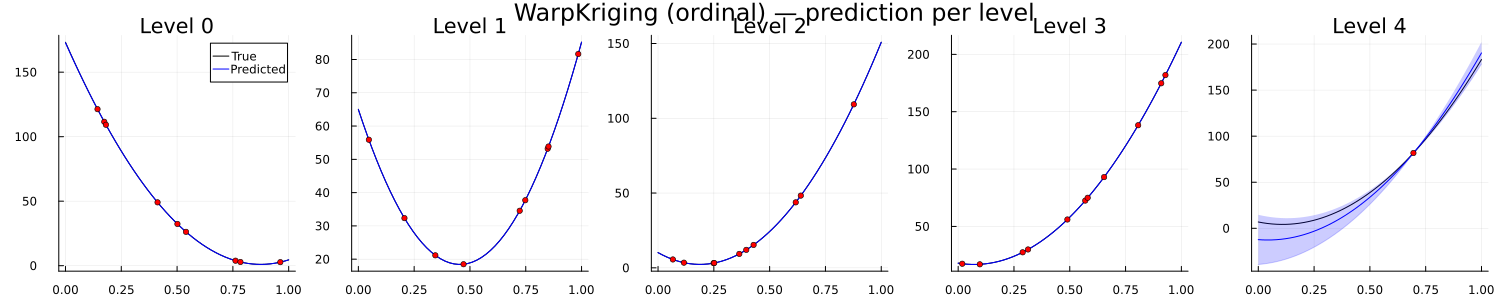

In [5]:
x2_grid = collect(range(0, 1, length=50))

plts = []
for lvl in 0:L-1
    X_pred = hcat(fill(Float64(lvl), 50), x2_grid)
    pred = predict(wk, X_pred; return_stdev=true)
    mu = pred.mean
    sd = pred.stdev

    # True Branin at this level's center
    X_true = hcat(fill(centers[lvl+1], 50), x2_grid)
    y_true = branin(X_true)

    p = plot(x2_grid, y_true, color=:black, label=lvl==0 ? "True" : "",
             title="Level $lvl", xlabel="x₂", ylabel=lvl==0 ? "Branin" : "")
    plot!(p, x2_grid, mu, color=:blue, label=lvl==0 ? "Predicted" : "")
    plot!(p, x2_grid, mu .- 2 .* sd, fillrange=mu .+ 2 .* sd,
          alpha=0.2, color=:blue, label="")

    mask = x1_level .== lvl
    scatter!(p, x2[mask], y[mask], color=:red, ms=3, label="")
    push!(plts, p)
end
plot(plts..., layout=(1, L), size=(300*L, 300),
     plot_title="WarpKriging (ordinal) — prediction per level")

## 5. Model inspection

Key fitted parameters: length-scales $\theta$, variance $\sigma^2$, log-likelihood, and warping specification.

In [6]:
println("Kernel       : ", kernel(wk))
println("Theta (range): ", round.(theta(wk), digits=4))
println("Sigma2       : ", round(sigma2(wk), digits=4))
println("LogLikelihood: ", round(log_likelihood(wk), digits=4))
println("Feature dim  : ", feature_dim(wk))
println("Warping      : ", warping(wk))

Kernel       : matern5_2
Theta (range): 

[5.559, 6.1562]
Sigma2       : 1.085125546e6
LogLikelihood: -25.6883
Feature dim  : 

2
Warping      : 

["ordinal(5)", "kumaraswamy"]
